# House price dataset model performance

In [68]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures, SmartCorrelatedSelection
from category_encoders import TargetEncoder
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import statsmodels.api as sm
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

In [69]:
data = pd.read_csv('../houseprice.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [70]:
print("Всего пропусков в исходном наборе:", data.isnull().sum().sum())

Всего пропусков в исходном наборе: 7829


In [71]:
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.isnull().sum().sum(),
      X_test.isnull().sum().sum())

6227 1602


## Missing Values Imputer

In [73]:
class MissingValueImputer(BaseEstimator, TransformerMixin):
   
    def __init__(self, cols_fill_no_option, cols_fill_zero):
        self.cols_fill_no_option = cols_fill_no_option
        self.cols_fill_zero = cols_fill_zero

    def fit(self, X, y=None):
        self.most_freq_electrical_ = X['Electrical'].mode()[0]
        self.lf_medians_ = X.groupby('Neighborhood')['LotFrontage'].median().to_dict()
        self.global_lf_median_ = X['LotFrontage'].median()
        return self

    def transform(self, X):
        df = X.copy()

        # Категории без объекта -'no_option'
        for col in self.cols_fill_no_option:
            df[col] = df[col].fillna('no_option')

        # 'Electrical' - мода
        df['Electrical'] = df['Electrical'].fillna(self.most_freq_electrical_)

        # Флаг пропуска LotFrontage
        df['LotFrontage_missing'] = df['LotFrontage'].isnull().astype(int)

        # Заполняем LotFrontage: сначала по Neighborhood, иначе глобальной медианой
        df['LotFrontage'] = (
            df['LotFrontage']
              .fillna(df['Neighborhood'].map(self.lf_medians_))
              .fillna(self.global_lf_median_))

        # cols_fill_zero: GarageYrBlt → YearBuilt, остальные → 0
        for col in self.cols_fill_zero:
            if col == 'GarageYrBlt':
                df[col] = df[col].fillna(df['YearBuilt'])
            else:
                df[col] = df[col].fillna(0)

        return df

cols_fill_no_option = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature']

cols_fill_zero = ['MasVnrArea', 'GarageYrBlt']

mvi = MissingValueImputer(cols_fill_no_option, cols_fill_zero)
mvi.fit(X_train, y_train)

X_train_imputed = mvi.transform(X_train)
X_test_imputed = mvi.transform(X_test)

print("Пропусков после MVI — X_train_imputed:", X_train_imputed.isnull().sum().sum(),
      ", X_test_imputed:", X_test_imputed.isnull().sum().sum())

Пропусков после MVI — X_train_imputed: 0 , X_test_imputed: 0


## Удаление константных, дублированных и сильно коррелированных признаков

In [74]:
selection_pipeline = Pipeline([
    ('drop_const', DropConstantFeatures(tol=0.98)),
    ('drop_dup', DropDuplicateFeatures()),
    ('drop_corr', SmartCorrelatedSelection(method='pearson', threshold=0.95))])

X_train_sel = selection_pipeline.fit_transform(X_train_imputed)
X_test_sel = selection_pipeline.transform(X_test_imputed)

print("Размерность после удаления X_train_sel:", X_train_sel.shape,
      ", X_test_sel:", X_test_sel.shape)

Размерность после удаления X_train_sel: (1168, 73) , X_test_sel: (292, 73)


## Деление признаков по типам 

In [75]:
qual_scale   = ['Po', 'Fa', 'TA', 'Gd', 'Ex']  # шкала качества «Плохое→Отличное»
garage_scale = ['no_option', 'Unf', 'RFn', 'Fin'] # шкала отделки гаража
paved_scale  = ['N', 'P', 'Y']  # шкала асфальт подъезда


ordinal_vars = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond','KitchenQual',
    'GarageQual','GarageFinish','PoolQC','PavedDrive'
]
ordinal_cats = [
    qual_scale, qual_scale, qual_scale, qual_scale, qual_scale,
    garage_scale, qual_scale, qual_scale, paved_scale
]

# Оставляем только те порядковые, что остались после селекции
ordinal_vars = [col for col in ordinal_vars if col in X_train_sel.columns]

# Остальные категориальные (object) → TargetEncoder
all_cat = X_train_sel.select_dtypes(include='object').columns.tolist()
cat_vars = [c for c in all_cat if c not in ordinal_vars]

# Все числовые после селекции, убираем константные (IQR=0)
num_vars = X_train_sel.select_dtypes(include=['int64','float64']).columns.tolist()
num_vars = [
    col for col in num_vars
    if X_train_sel[col].quantile(0.75) - X_train_sel[col].quantile(0.25) > 0]

print("Числовые после удаления констант:", num_vars)
print("Порядковые:", ordinal_vars)
print("Категориальные (для TargetEncoder):", cat_vars)

Числовые после удаления констант: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'MoSold', 'YrSold']
Порядковые: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'KitchenQual', 'GarageQual', 'GarageFinish', 'PavedDrive']
Категориальные (для TargetEncoder): ['MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'FireplaceQu', 'GarageType', 'GarageCond', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## ColumnTransformer для предобработки

In [76]:
numeric_pipeline = Pipeline([
    ('winsorizer', Winsorizer(capping_method='gaussian', tail='both', fold=1.5))]) # iqr тоже не плохо отрабатывает

ordinal_pipeline = Pipeline([
    ('ord_enc', OrdinalEncoder(
        categories=[ordinal_cats[i] for i, col in enumerate(ordinal_vars)],
        handle_unknown='use_encoded_value', unknown_value=-1))])

categorical_pipeline = Pipeline([
    ('target_enc', TargetEncoder(cols=cat_vars, smoothing=0.3))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_vars),
    ('ord', ordinal_pipeline, ordinal_vars),
    ('cat', categorical_pipeline, cat_vars),
], remainder='drop')

## Подготовка AdaBoost и Grid-Search

In [77]:
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 1.0],
   # 'loss': ['linear', 'square', 'exponential']
}

# Пайплайн: предобработка → AdaBoost
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', AdaBoostRegressor(random_state=42))])

# Лог-трансформация таргета через ttr
ttr = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1)

# Параметры оптимизации внутри TTR - 'regressor__model__<param>'
param_grid = {
    f'regressor__model__{param_name}': values
    for param_name, values in ada_params.items()}

gs = GridSearchCV(
    estimator=ttr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    refit=True)

gs.fit(X_train_sel, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('prep',
                                                                             ColumnTransformer(transformers=[('num',
                                                                                                              Pipeline(steps=[('winsorizer',
                                                                                                                               Winsorizer(fold=1.5,
                                                                                                                                          tail='both'))]),
                                                                                                              ['Id',
                                                                                                               'MSSubClass',
                                                                                                               'LotFrontage',
                                                                                                               'LotArea',
                                                                                                               'OverallQual',
                                                                                                               'OverallCond',
                                                                                                               'YearBuilt',
                                                                                                               'YearRemodAdd',
                                                                                                               'MasVnrAre...
                                                                                                               'HeatingQC',
                                                                                                               'CentralAir',
                                                                                                               'Electrical',
                                                                                                               'Functional',
                                                                                                               'FireplaceQu',
                                                                                                               'GarageType',
                                                                                                               'GarageCond',
                                                                                                               'Fence',
                                                                                                               'MiscFeature',
                                                                                                               'SaleType',
                                                                                                               'SaleCondition'])])),
                                                                            ('model',
                                                                             AdaBoostRegressor(random_state=42))])),
             n_jobs=-1,
             param_grid={'regressor__model__learning_rate': [0.01, 0.1, 1.0],
                         'regressor__model__n_estimators': [50, 100]},
             scoring='neg_mean_absolute_error', verbose=1)

In [78]:
best_ttr = gs.best_estimator_

# Предсказания и метрики
y_pred_tr = best_ttr.predict(X_train_sel)
y_pred_te = best_ttr.predict(X_test_sel)

results = {
    'Model': 'AdaBoost',
    'BestParams': gs.best_params_,
    'MAE_Train': mean_absolute_error(y_train, y_pred_tr),
    'MAE_Test': mean_absolute_error(y_test,  y_pred_te),
    'RMSE_Train': np.sqrt(mean_squared_error(y_train, y_pred_tr)),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test,  y_pred_te)),
    'R2_Train': r2_score(y_train, y_pred_tr),
    'R2_Test': r2_score(y_test, y_pred_te)}

print(results)

{'Model': 'AdaBoost', 'BestParams': {'regressor__model__learning_rate': 1.0, 'regressor__model__n_estimators': 50}, 'MAE_Train': np.float64(20830.678335457484), 'MAE_Test': np.float64(21157.438934257483), 'RMSE_Train': np.float64(29337.978918666908), 'RMSE_Test': np.float64(33507.17720365106), 'R2_Train': 0.8556945700464915, 'R2_Test': 0.8536267045455159}


## Визуализация метрик (Train vs Test)

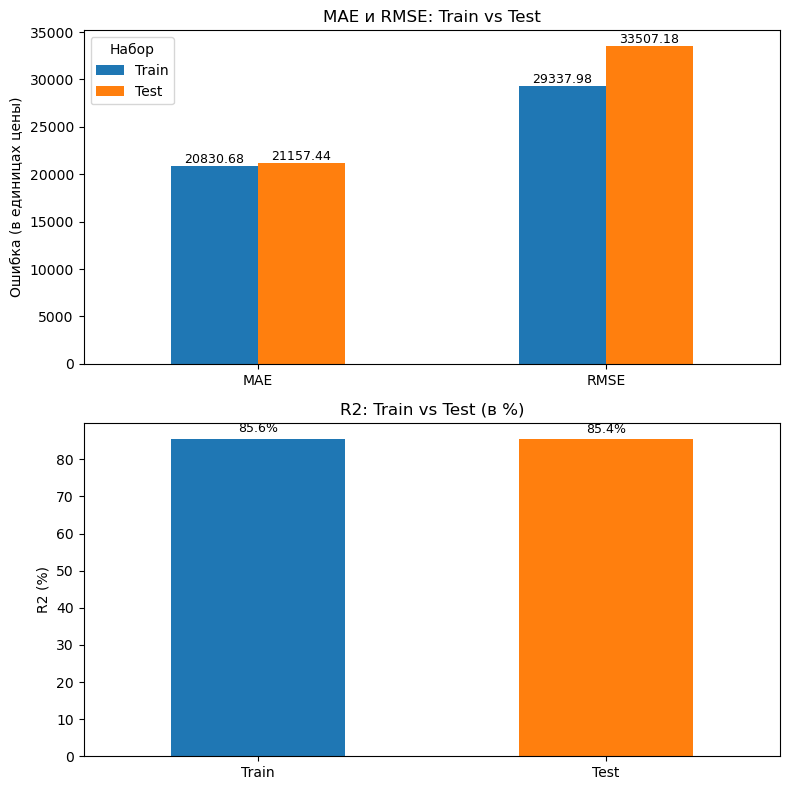

In [79]:
# Собираем общую таблицу метрик
metrics_df = pd.DataFrame({
    'MAE':  [results['MAE_Train'],  results['MAE_Test']],
    'RMSE': [results['RMSE_Train'], results['RMSE_Test']],
    'R2':   [results['R2_Train'],   results['R2_Test']]}, index=['Train', 'Test']).T

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 8), sharex=False)

# MAE и RMSE 
df_mae_rmse = metrics_df.loc[['MAE', 'RMSE']]  # берём только MAE и RMSE
ax1 = df_mae_rmse.plot(
    kind='bar',
    ax=axs[0],
    rot=0,
    title='MAE и RMSE: Train vs Test')

# Добавляем подписи значений над столбиками
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.2f',    # два знака после запятой
        label_type='edge',
        fontsize=9)
ax1.set_ylabel('Ошибка (в единицах цены)')
ax1.legend(title='Набор')

# R2 (в процентах) 
r2_perc = metrics_df.loc['R2'] * 100
ax2 = axs[1]
r2_perc.plot(
    kind='bar',
    ax=ax2,
    color=['tab:blue', 'tab:orange'],
    rot=0)
ax2.set_title('R2: Train vs Test (в %)')
ax2.set_ylabel('R2 (%)')
ax2.set_xticklabels(['Train', 'Test'], rotation=0)

# Подписи прямо над R2-барами
for i, val in enumerate(r2_perc):
    ax2.text(
        i, 
        val + 1,              # чуть выше вершины бара
        f"{val:.1f}%",        
        ha='center',
        va='bottom',
        fontsize=9)

plt.tight_layout()
plt.show()

## Анализ остатков для AdaBoost

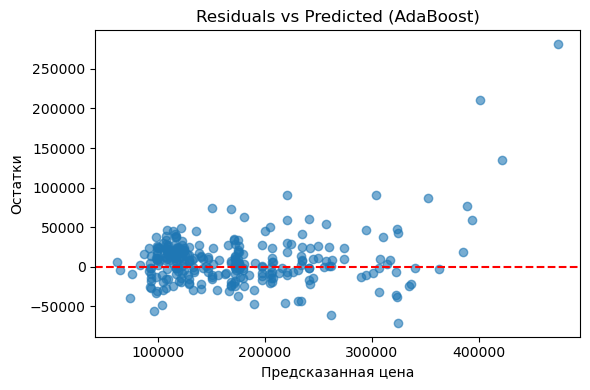

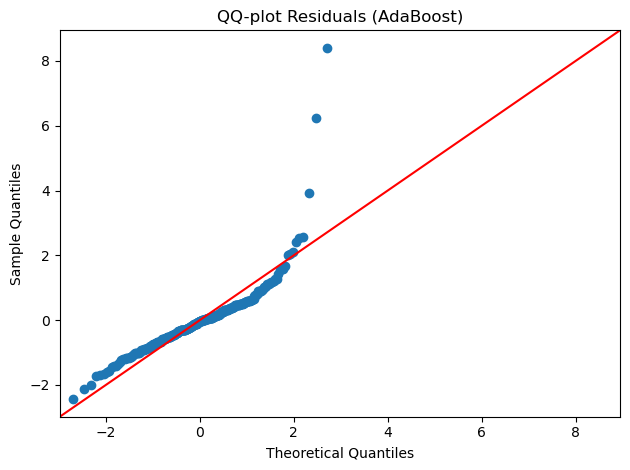

In [80]:
y_pred = best_ttr.predict(X_test_sel)
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остатки')
plt.title('Residuals vs Predicted (AdaBoost)')
plt.tight_layout()
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ-plot Residuals (AdaBoost)')
plt.tight_layout()
plt.show()

### В целом эти два графика показывают, что AdaBoost-модель стабильна и не переобучена (основная «область» остатков сосредоточена около нуля и не сильно расширяется), но она не в состоянии полностью «поймать» самые дорогие и редкие случаи, из-за чего формируется тяжёлый положительный хвост остатков

## Feature Importance для AdaBoost

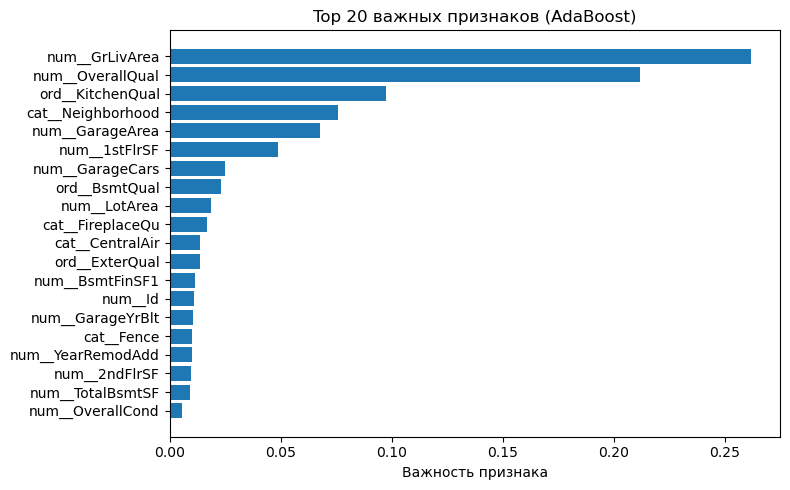

In [81]:
best_estimator = best_ttr.regressor_
model_inner = best_estimator.named_steps['model']

# Получаем имена признаков после 'prep'
features_pipeline = Pipeline([
    ('prep', preprocessor)])
features_pipeline.fit(X_train_sel, y_train)
feature_names = features_pipeline.named_steps['prep'].get_feature_names_out()

importances = model_inner.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 20
plt.figure(figsize=(8, 5))
plt.barh(fi_df['feature'].head(top_n)[::-1], fi_df['importance'].head(top_n)[::-1])
plt.xlabel('Важность признака')
plt.title('Top 20 важных признаков (AdaBoost)')
plt.tight_layout()
plt.show()

## ВЫВОДЫ ПО МОДЕЛИ

Hа основе полученных метрик и поведения модели можно сделать следующие ключевые выводы:

Качество объяснения дисперсии (R2)

Высокий R2 и небольшое падение при переходе от train к test говорит о том, что модель AdaBoost хорошо описывает связи в данных и практически не переобучается. Иными словами, примерно 85 % дисперсии SalePrice удаётся «объяснить» предикторами.

Величины ошибок (MAE и RMSE)
MAE на обучении и на тесте показали близкие значения, что подтверждает отсутствие серьёзного переобучения. MAE показывает среднюю абсолютную ошибку предсказания, и её значение говорит о том, что в среднем модель ошибается на эту сумму при прогнозировании цены.

RMSE (корень из MSE) в абсолютном выражении чуть больше MAE, что естественно, поскольку RMSE даёт больший вес «большим» отклонениям. Но разница между RMSE на train и на test также невелика, что говорит о стабильности модели.
MAE и RMSE оба этих показателя на обучении и тесте сопоставимы, то есть модель не «запоминает» шум, а адекватно работает на тестовых данных.